<a href="https://colab.research.google.com/github/souhaylelhammadi/analytique-des-donn-es-et-informatique-d-cisionnelle/blob/main/R%C3%A9gression_lin%C3%A9aire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
#1Générer un dataset artificiel : y=3x+2+ε

#Permet d’obtenir les mêmes valeurs aléatoires à chaque exécution
np.random.seed(0)
#Crée 50 valeurs régulièrement espacées entre 0 et 10.
x=np.linspace(0,10,50)

noise =np.random.normal(0,2,size=len(x))
#Génère un bruit aléatoire :moyenne = 0 écart-type = 2 size=len(x) → une valeur de bruit par observation.

y=3*x+2+noise

#2 Implémentation des moindres carrés
#y=Xβ+ε
X=np.c_[np.ones(len(x)),x] #Construit la matrice de design X np.ones(len(x)) → colonne de 1 pour le biais (intercept) np.c_[] → concatène les colonnes.

#Applique la formule analytique des moindres carrés
beta = np.linalg.inv(X.T @ X) @ X.T @ y
#X.T : transposée de X
#X.T @ X : produit matriciel
#np.linalg.inv(...) : inverse de la matrice
#@ X.T @ y : projection sur y

beta0,beta1=beta
print(beta0,beta1)


3.6927410376163867 2.717675501401961


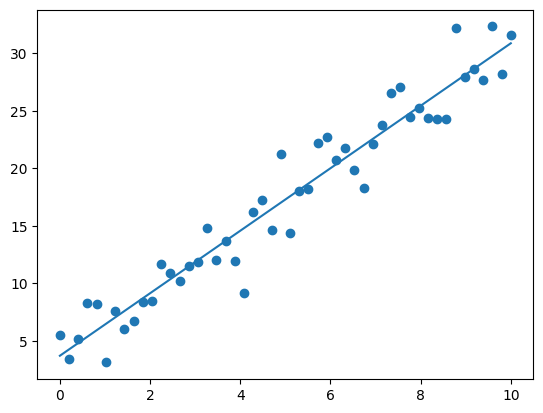

In [10]:
#3 Visualisation
y_pred=beta0 + beta1*x
plt.scatter(x,y)
plt.plot(x,y_pred)
plt.show()

In [12]:
#4 MSE
mse = np.mean((y - y_pred)**2)
print("MSE:", mse)


MSE: 4.3758700917125655


TP2


In [13]:
from sklearn.datasets import make_regression

X,y=make_regression(n_samples=100,n_features=3,noise=10)

X_b=np.c_[np.ones(len(X)),X]
beta =np.linalg.inv(X_b.T @ X_b ) @ X_b.T @ y
print("Coefficients :", beta)

Coefficients : [-0.39414901 27.48816903 36.52804485 36.82067756]


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)
print(model.intercept_, model.coef_)


-0.39414900937465447 [27.48816903 36.52804485 36.82067756]


In [17]:
import numpy as np

np.random.seed(0)

# DONNÉES COHÉRENTES
x = np.linspace(0, 10, 50)
noise = np.random.normal(0, 2, size=len(x))
y = 3*x + 2 + noise

# Gradient Descent
alpha = 0.01
n_iter = 1000
beta = np.zeros(2)

for _ in range(n_iter):
    y_pred = beta[0] + beta[1]*x
    d_beta0 = -2 * np.mean(y - y_pred)
    d_beta1 = -2 * np.mean((y - y_pred) * x)
    beta[0] -= alpha * d_beta0
    beta[1] -= alpha * d_beta1

print(beta)


[3.67218748 2.7207504 ]


In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 3)
y shape: (50,)


In [25]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

# DONNÉES COHÉRENTES
X, y = make_regression(
    n_samples=100,
    n_features=3,
    noise=10,
    random_state=0
)

# Ridge
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

# Lasso
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1))
])

ridge.fit(X, y)
lasso.fit(X, y)

print("Ridge:", ridge.named_steps['ridge'].coef_)
print("Lasso:", lasso.named_steps['lasso'].coef_)


Ridge: [39.05982981  7.89193732 62.6918473 ]
Lasso: [39.39031542  7.8160575  63.2517716 ]
